<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Perception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install nuscenes-devkit pyquaternion pyyaml tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
esda 2.8.1 requires shapely>=2.1, but you have shapely 2.0.7 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=

In [6]:
import os, json, random
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/nuscenes"   # you provided this ✅
VERSION = "v1.0-mini"
DATASET_ROOT = DATA_ROOT

assert os.path.exists(DATASET_ROOT), f"Not found: {DATASET_ROOT}"

CFG = {
  "version": VERSION,
  "dataroot": DATASET_ROOT,
  "bev": {
    "x_min": -25.0, "x_max":  25.0,
    "y_min": -25.0, "y_max":  25.0,
    "resolution": 0.25,
    "z_min": -3.0, "z_max":  2.0,
  },
  "export": {
    "local_out_dir": "/content/bev_dataset",           # FAST local
    "drive_out_dir": "/content/drive/MyDrive/bev_dataset",  # final destination
    "zip_name": "bev_dataset.zip",
    "max_scenes": 3,              # start small
    "max_frames_per_scene": 60,   # start small
    "seed": 42
  }
}

print("Dataset root:", DATASET_ROOT)
print("Local export:", CFG["export"]["local_out_dir"])
print("Drive export:", CFG["export"]["drive_out_dir"])

Dataset root: /content/drive/MyDrive/nuscenes
Local export: /content/bev_dataset
Drive export: /content/drive/MyDrive/bev_dataset


In [7]:
print('Uninstalling numpy, scipy, and scikit-learn...')
!pip uninstall -y numpy scipy scikit-learn

print('Installing compatible versions...')
!pip install numpy==1.24.0 --force-reinstall
!pip install scipy scikit-learn

print('Installation complete. Please rerun the previous cells if needed.')

Uninstalling numpy, scipy, and scikit-learn...
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Installing compatible versions...
  Using cached numpy-1.24.0.tar.gz (10.9 MB)
ERROR: Operation cancelled by user
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2

Installation complete. Please rerun the previous cells if needed.


In [8]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version=CFG["version"], dataroot=CFG["dataroot"], verbose=True)
print("Scenes:", len(nusc.scene))

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.859 seconds.
Reverse indexing ...
Done reverse indexing in 0.2 seconds.
Scenes: 10


In [9]:
import os
import numpy as np
from pyquaternion import Quaternion
from nuscenes.utils.data_classes import LidarPointCloud
from nuscenes.utils.geometry_utils import transform_matrix

def load_lidar_xyz_ego(nusc, sample_token: str, dataroot: str) -> np.ndarray:
    """
    Returns xyz points in EGO frame at the lidar timestamp. Shape: (N, 3)
    """
    sample = nusc.get("sample", sample_token)
    lidar_token = sample["data"]["LIDAR_TOP"]
    sd = nusc.get("sample_data", lidar_token)

    # nuScenes uses 'filename' (not 'file_name') :contentReference[oaicite:1]{index=1}
    lidar_path = os.path.join(dataroot, sd["filename"])
    pc = LidarPointCloud.from_file(lidar_path)

    # Lidar sensor -> Ego frame
    cs = nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])
    pc.transform(transform_matrix(cs["translation"], Quaternion(cs["rotation"]), inverse=False))

    xyz = pc.points[:3, :].T  # (N, 3)
    return xyz

def rasterize_bev_occupancy(xyz_ego: np.ndarray, bev_cfg: dict, min_points_per_cell: int = 1) -> np.ndarray:
    x_min, x_max = bev_cfg["x_min"], bev_cfg["x_max"]
    y_min, y_max = bev_cfg["y_min"], bev_cfg["y_max"]
    res = bev_cfg["resolution"]
    z_min = bev_cfg.get("z_min", None)
    z_max = bev_cfg.get("z_max", None)

    x = xyz_ego[:, 0]
    y = xyz_ego[:, 1]
    z = xyz_ego[:, 2]

    mask = (x >= x_min) & (x < x_max) & (y >= y_min) & (y < y_max)
    if z_min is not None:
        mask &= (z >= z_min)
    if z_max is not None:
        mask &= (z < z_max)

    x = x[mask]
    y = y[mask]

    H = int((x_max - x_min) / res)
    W = int((y_max - y_min) / res)

    counts = np.zeros((H, W), dtype=np.uint16)

    x_idx = ((x - x_min) / res).astype(np.int32)
    y_idx = ((y - y_min) / res).astype(np.int32)

    x_idx = np.clip(x_idx, 0, H - 1)
    y_idx = np.clip(y_idx, 0, W - 1)

    np.add.at(counts, (x_idx, y_idx), 1)
    occ = (counts >= min_points_per_cell).astype(np.uint8)
    return occ

xyz: (34400, 3) occ: (200, 200) occupied cells: 4203


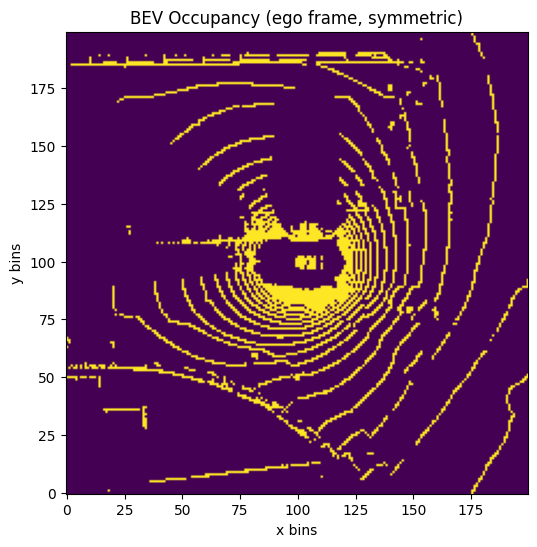

In [10]:
import matplotlib.pyplot as plt
import random

scene = random.choice(nusc.scene)
token = scene["first_sample_token"]
xyz = load_lidar_xyz_ego(nusc, token, CFG["dataroot"])
occ = rasterize_bev_occupancy(xyz, CFG["bev"])

print("xyz:", xyz.shape, "occ:", occ.shape, "occupied cells:", int(occ.sum()))

plt.figure(figsize=(6,6))
plt.imshow(occ.T, origin="lower")
plt.title("BEV Occupancy (ego frame, symmetric)")
plt.xlabel("x bins")
plt.ylabel("y bins")
plt.show()

In [11]:
from tqdm import tqdm
import os, json

def iter_scene_samples(nusc, scene_record, max_frames=None):
    token = scene_record["first_sample_token"]
    count = 0
    while token:
        yield token
        count += 1
        if max_frames is not None and count >= max_frames:
            break
        sample = nusc.get("sample", token)
        token = sample["next"]

def export_bev_dataset(nusc, cfg):
    out_dir = cfg["export"]["local_out_dir"] # Changed from "out_dir" to "local_out_dir"
    os.makedirs(out_dir, exist_ok=True)

    # Save meta/config
    with open(os.path.join(out_dir, "meta.json"), "w") as f:
        json.dump(cfg, f, indent=2)

    scenes = list(nusc.scene)
    random.seed(cfg["export"]["seed"])
    random.shuffle(scenes)
    scenes = scenes[: cfg["export"]["max_scenes"]]

    train_dir = os.path.join(out_dir, "train")
    os.makedirs(train_dir, exist_ok=True)

    for scene in scenes:
        scene_name = scene["name"]
        scene_out = os.path.join(train_dir, scene_name)
        os.makedirs(scene_out, exist_ok=True)

        tokens = list(iter_scene_samples(nusc, scene, max_frames=cfg["export"]["max_frames_per_scene"]))
        for token in tqdm(tokens, desc=f"Export {scene_name}"):
            xyz = load_lidar_xyz_ego(nusc, token, cfg["dataroot"])
            occ = rasterize_bev_occupancy(xyz, cfg["bev"], min_points_per_cell=1)
            np.save(os.path.join(scene_out, f"{token}_occ.npy"), occ)

    return out_dir

out_dir = export_bev_dataset(nusc, CFG)
print("Export complete:", out_dir)


Export scene-0553: 100%|██████████| 41/41 [00:00<00:00, 54.85it/s]

Export complete: /content/bev_dataset


Exported files: 123


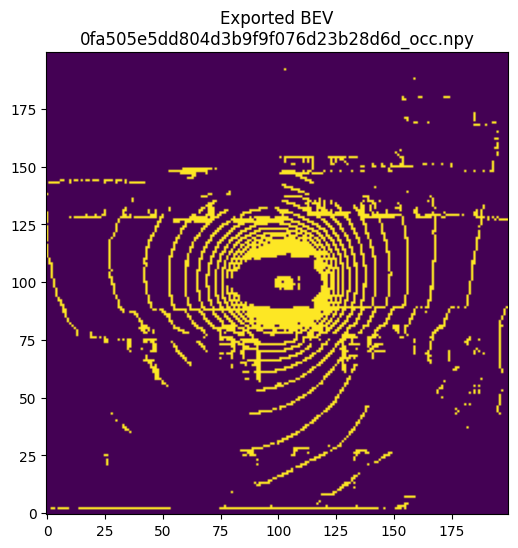

In [12]:
import glob, random
import numpy as np
import matplotlib.pyplot as plt

files = glob.glob(os.path.join(CFG["export"]["local_out_dir"], "train", "*", "*_occ.npy"))
print("Exported files:", len(files))

path = random.choice(files)
occ = np.load(path)

plt.figure(figsize=(6,6))
plt.imshow(occ.T, origin="lower")
plt.title(f"Exported BEV\n{os.path.basename(path)}")
plt.show()

occ shape: (200, 200) occupied cells: 4434


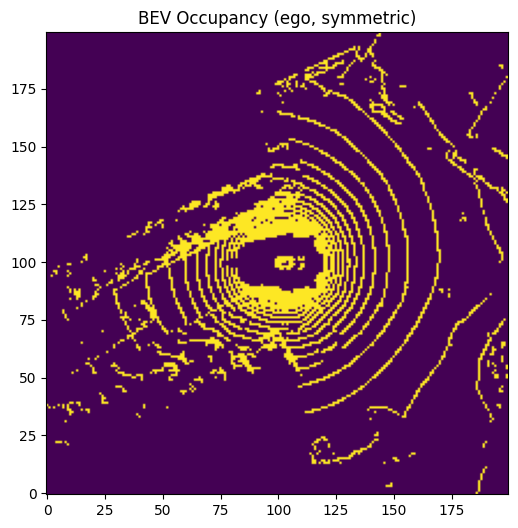

occ shape: (200, 200) occupied cells: 4496


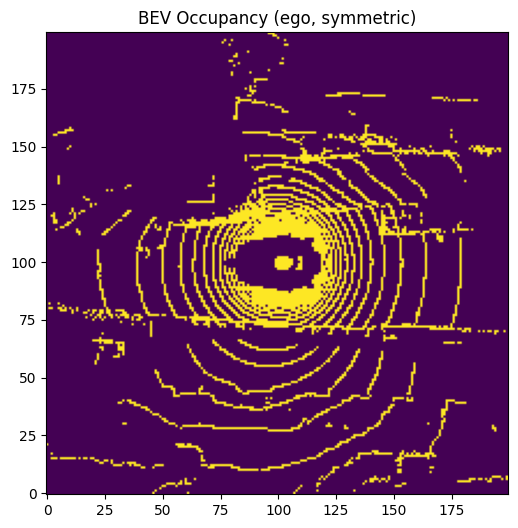

occ shape: (200, 200) occupied cells: 4496


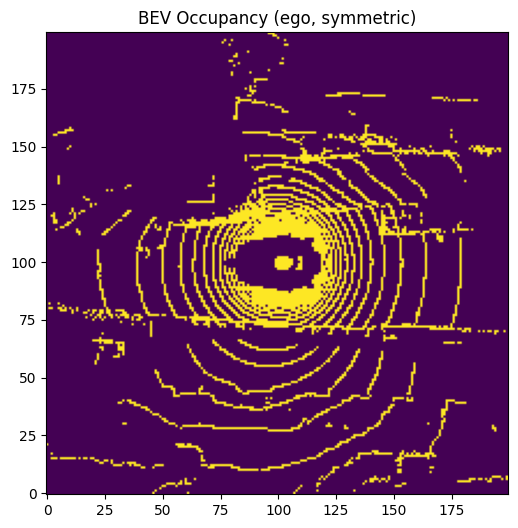

In [13]:
import random
import matplotlib.pyplot as plt

def show_bev_for_token(sample_token):
    xyz = load_lidar_xyz_ego(nusc, sample_token, CFG["dataroot"])
    occ = rasterize_bev_occupancy(xyz, CFG["bev"])
    print("occ shape:", occ.shape, "occupied cells:", int(occ.sum()))
    plt.figure(figsize=(6,6))
    plt.imshow(occ.T, origin="lower")
    plt.title("BEV Occupancy (ego, symmetric)")
    plt.show()

# pick 3 random scenes and show first sample from each
for _ in range(3):
    scene = random.choice(nusc.scene)
    token = scene["first_sample_token"]
    show_bev_for_token(token)

In [14]:
CFG["export"]["max_scenes"] = 2
CFG["export"]["max_frames_per_scene"] = 40

In [15]:
import os, glob
files = glob.glob("/content/bev_dataset/train/*/*_occ.npy")
print("Exported:", len(files))
print("Example:", files[0])

Exported: 123
Example: /content/bev_dataset/train/scene-1077/a401b5ee030547ab8678a563f13b4731_occ.npy


In [16]:
# all points
occ_all = rasterize_bev_occupancy(xyz, CFG["bev"], min_points_per_cell=1)

# no-ground (simple height threshold)
bev_cfg_ng = dict(CFG["bev"])
bev_cfg_ng["z_min"] = -1.4
occ_noground = rasterize_bev_occupancy(xyz, bev_cfg_ng, min_points_per_cell=1)

In [17]:
import os

train_dir = os.path.join(CFG["export"]["local_out_dir"], "train")
sce_out = os.path.join(train_dir, scene["name"])
os.makedirs(scene_out, exist_ok=True)

np.save(os.path.join(scene_out, f"{token}_occ_all.npy"), occ_all)
np.save(os.path.join(scene_out, f"{token}_occ_ng.npy"), occ_noground)

NameError: name 'scene_out' is not defined